# INFO-F-422 — Task 2a: Parameter Selection Approach

In this notebook, we determine the optimal lags ($n_a$, $n_b$) and delay ($d$) for our NARX models. 
Unlike linear systems where ACF/PACF plots are usually enough, NARX models are highly non-linear. That's why we rely on **Mutual Information (MI)** to measure the non-linear dependency between past inputs/outputs and our future target $y(k+1)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# set a seed so the results are exactly reproducible every time we run the notebook
np.random.seed(42)

In [2]:
def sim_narx1(N, noise, u=None):
    # init to zero (handles y(0)=0 automatically)
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    
    # random input if none is provided
    if u is None:
        u = np.random.uniform(-1, 1, N + 1)
        
    std = np.sqrt(noise)
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # simulation loop (start at k=1 since we look 1 step back)
    for k in range(1, N):
        y1[k+1] = 0.5 * y2[k-1] + np.sin(y2[k]) + 0.3 * u[k-1] + w1[k+1]
        y2[k+1] = 0.5 * y1[k-1] + np.sin(y1[k]) + 0.2 * u[k] + w2[k+1]
        
    return u.reshape(-1, 1), np.column_stack((y1, y2))

def sim_narx2(N, noise, u=None):
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    
    # handle 2d input
    if u is None:
        u = np.random.uniform(-1, 1, (N + 1, 2))
    
    u1, u2 = u[:, 0], u[:, 1]
    std = np.sqrt(noise)
    
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # start at k=2 because the formula looks 2 steps back
    for k in range(2, N):
        
        # calculate y1
        num1 = y1[k] * y1[k-1] * y1[k-2] * (y1[k-2] - 1) * u2[k-1] + u2[k]
        den1 = 1 + y2[k-1]**2 + y2[k-2]**2
        y1[k+1] = (num1 / den1) + w1[k+1]
        
        # calculate y2
        num2 = y2[k] * y2[k-1] * y2[k-2] * (y2[k-2] - 1) * u1[k-1] + u1[k]
        den2 = 1 + y1[k-1]**2 + y1[k-2]**2
        y2[k+1] = (num2 / den2) + w2[k+1]
        
    return u, np.column_stack((y1, y2))

In [3]:

# dataset generation  
N_train = 2000  
N_test = 1000   
noise = 0.05    

print("generating narx1 data...")
u_train_1, y_train_1 = sim_narx1(N_train, noise)
u_test_1, y_test_1   = sim_narx1(N_test, noise)

print(f"narx1 train : u {u_train_1.shape}, y {y_train_1.shape}")
print(f"narx1 test  : u {u_test_1.shape}, y {y_test_1.shape}")

print("\ngenerating narx2 data...")

# Stabilisation du système NARX 2 pr eviter les overflow
noise_narx2 = 0.0001
u_doux_train = np.random.uniform(-0.1, 0.1, (N_train + 1, 2))
u_doux_test = np.random.uniform(-0.1, 0.1, (N_test + 1, 2))

u_train_2, y_train_2 = sim_narx2(N_train, noise_narx2, u=u_doux_train)
u_test_2, y_test_2   = sim_narx2(N_test, noise_narx2, u=u_doux_test)

print(f"narx2 train : u {u_train_2.shape}, y {y_train_2.shape}")
print(f"narx2 test  : u {u_test_2.shape}, y {y_test_2.shape}")

generating narx1 data...
narx1 train : u (2001, 1), y (2001, 2)
narx1 test  : u (1001, 1), y (1001, 2)

generating narx2 data...
narx2 train : u (2001, 2), y (2001, 2)
narx2 test  : u (1001, 2), y (1001, 2)


In [4]:
# we use sliding windows to create our feature matrix x and target vector y
def make_sliding_window(U, Y, na, nb, d):
    """
    U: input signal (N, n_inputs)
    Y: output signal (N, n_outputs)
    na: output lags to consider
    nb: input lags to consider
    d: delay for the input
    """
    n_samples = Y.shape[0]
    n_outputs = Y.shape[1]
    n_inputs  = U.shape[1]
    start = max(na, nb + d)
    X, Y_target = [], []
    
    for k in range(start, n_samples - 1):
        features = []
        for j in range(n_outputs):
            features.extend(Y[k - na + 1 : k + 1, j][::-1])

        for j in range(n_inputs):
            features.extend(U[k - d - nb + 1 : k - d + 1, j][::-1])
            
        X.append(features)
        Y_target.append(Y[k + 1]) 
        
    return np.array(X), np.array(Y_target)


computing mutual information for NARX1...


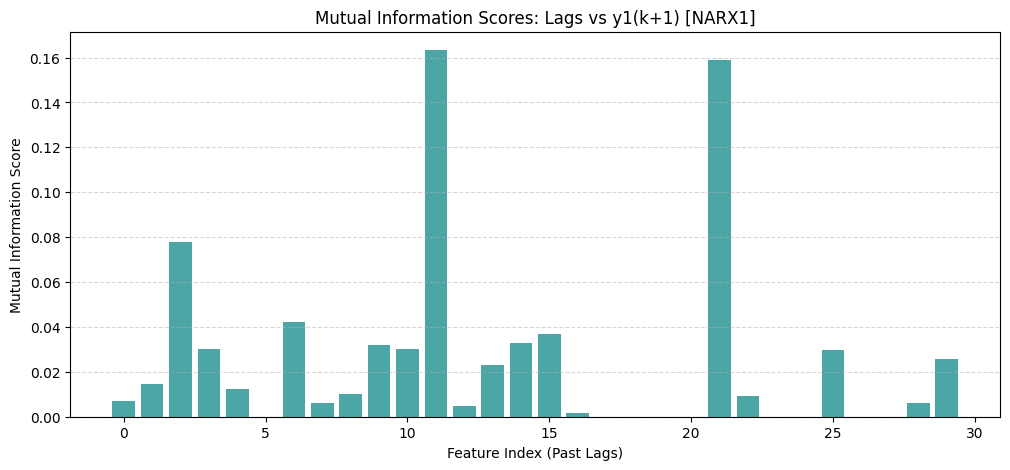


computing mutual information for NARX2...


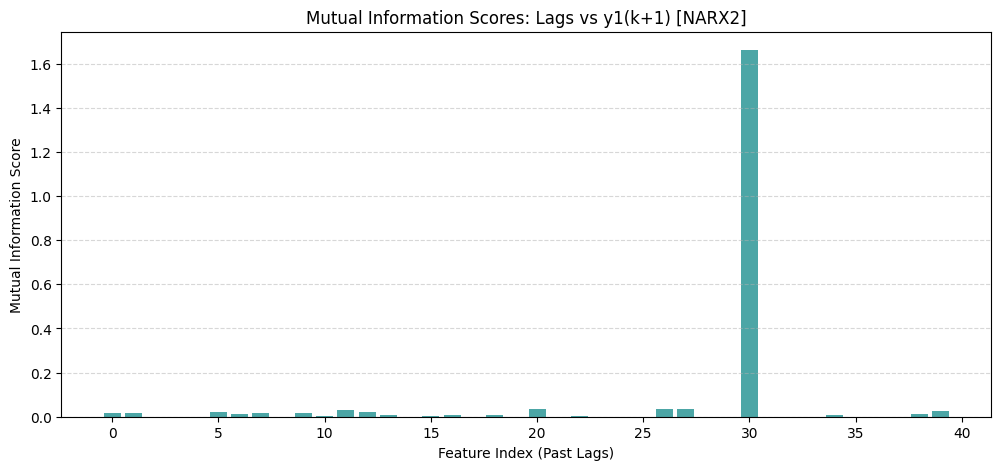

In [5]:
# we use MI to analyze which lags are most informative for predicting y(k+1) 
def analyze_mi_lags(U, Y, max_lag=10, name="NARX1"):
    print(f"\ncomputing mutual information for {name}...")
    
    # first with max lag and d=0 to see who is useful for predicting y(k+1)
    X_mega, Y_target = make_sliding_window(U, Y, na=max_lag, nb=max_lag, d=0)
    
    mi_scores = mutual_info_regression(X_mega, Y_target[:, 0], random_state=42)
    
    # graph
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(mi_scores)), mi_scores, color='teal', alpha=0.7)
    plt.title(f"Mutual Information Scores: Lags vs y1(k+1) [{name}]")
    plt.xlabel("Feature Index (Past Lags)")
    plt.ylabel("Mutual Information Score")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show() 
    
    return mi_scores

mi_narx1 = analyze_mi_lags(u_train_1, y_train_1, name="NARX1")
mi_narx2 = analyze_mi_lags(u_train_2, y_train_2, name="NARX2")